In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [ ]:
# raw GitHub CSV links
radiation = "https://raw.githubusercontent.com/charmaineyuen01/E11_Charmaine_Wes_Addie/refs/heads/main/data/final%20report/radiation.csv"
temp = "https://raw.githubusercontent.com/charmaineyuen01/E11_Charmaine_Wes_Addie/refs/heads/main/data/final%20report/pth.csv"
pm25 = "https://raw.githubusercontent.com/charmaineyuen01/E11_Charmaine_Wes_Addie/main/data/lab%20report/air_quality.csv"

# dataframe
rad_df = pd.read_csv(radiation)
temp_df = pd.read_csv(temp)
pm25_df = pd.read_csv(pm25)

#fix timestamps
rad_df["time_s"] = rad_df["timestamp"] - rad_df["timestamp"].iloc[0]
temp_df["time_s"] = temp_df["timestamp"] - temp_df["timestamp"].iloc[0]
pm25_df["time_s"] = pm25_df["timestamp"] - pm25_df["timestamp"].iloc[0]

# measurement locations
locations = {
    "Location 1: Kresge Library": (70, 670),
    "Location 2: Doe, North Reading Room": (1000, 1600),
    "Location 3: Mainstacks, Top Floor": (1950, 2550),
    "Location 4: Mainstacks, Bottom Floor": (2620, 3220),
    "Location 5: East Asian, Top Floor": (3790, 4390),
    "Location 6: East Asian, Bottom Floor": (4500, 5100),
}

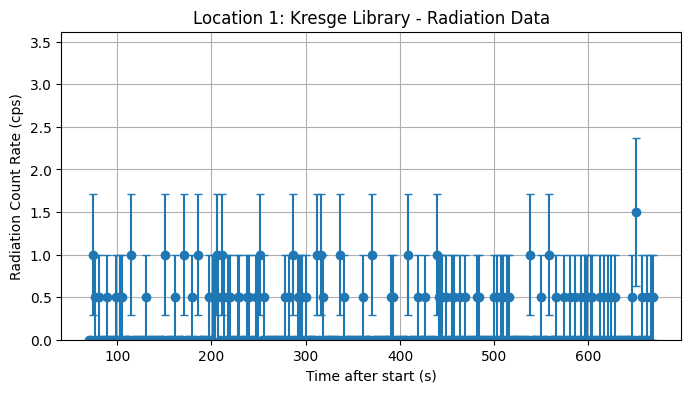

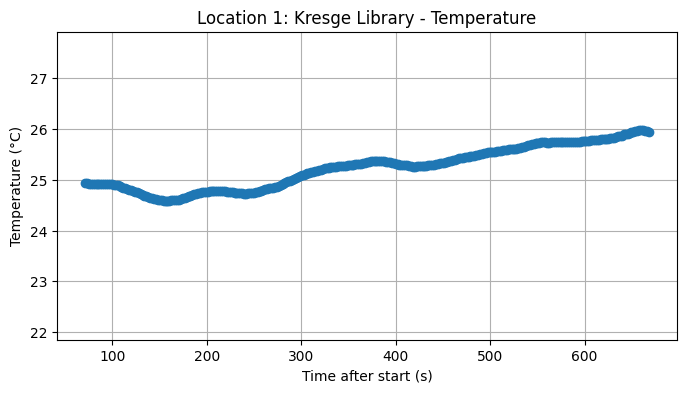

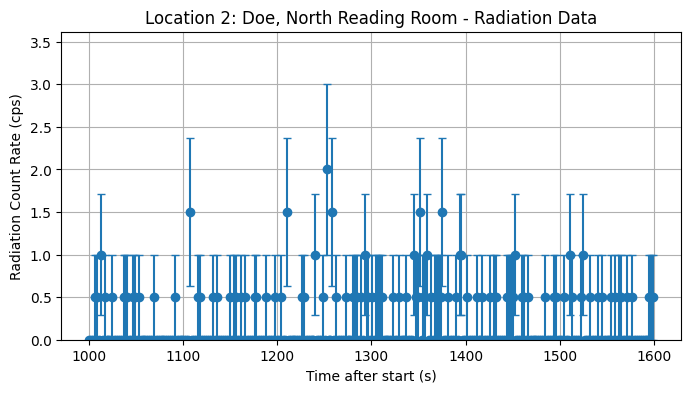

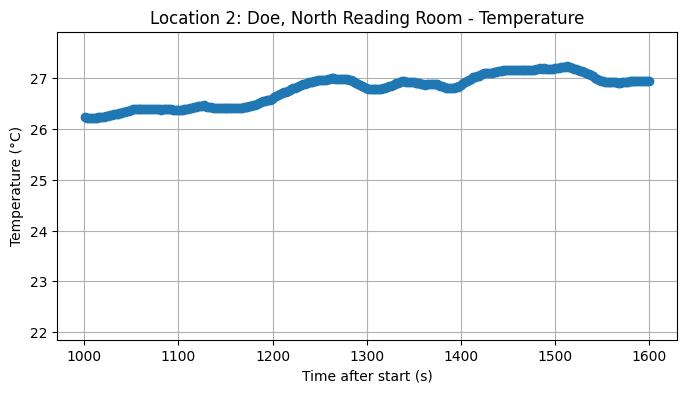

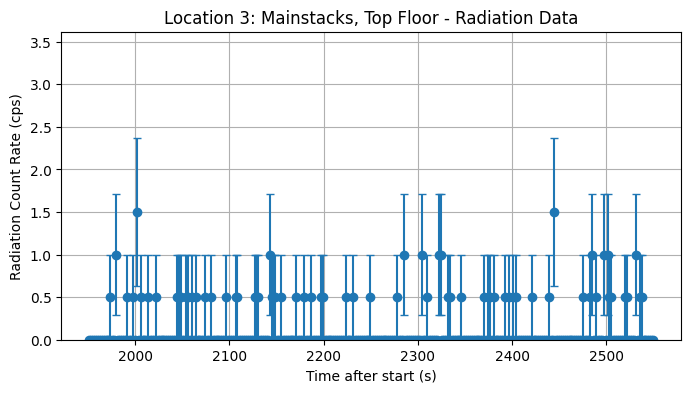

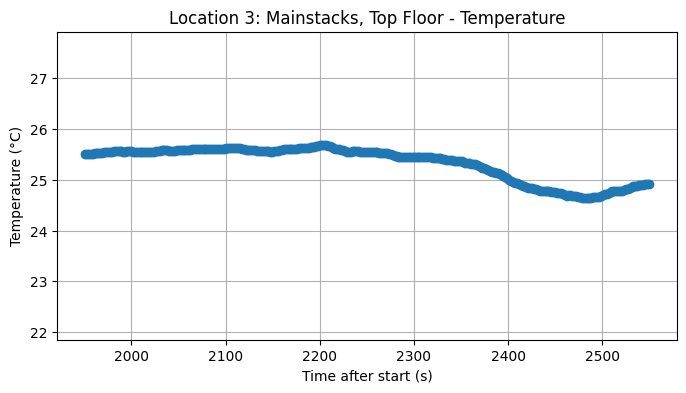

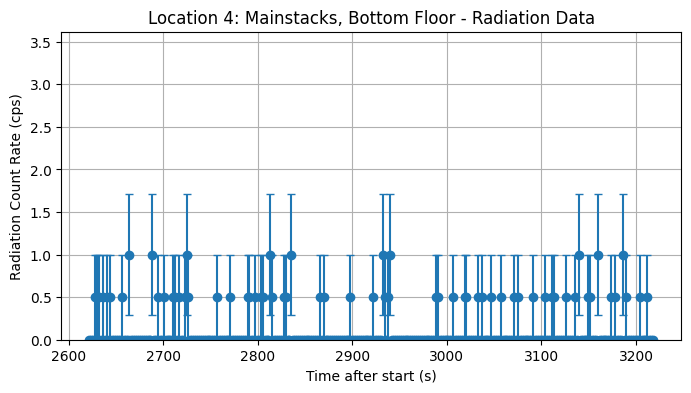

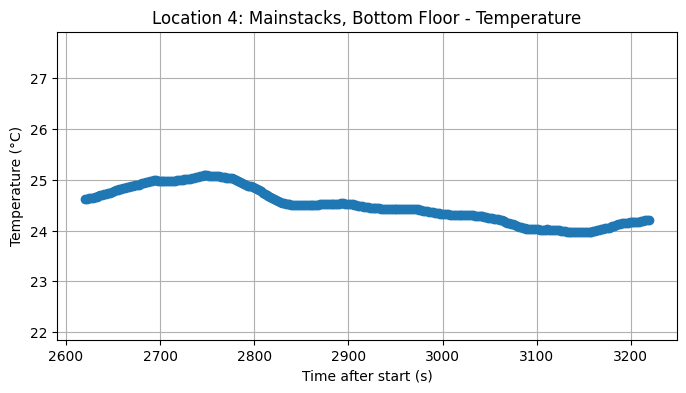

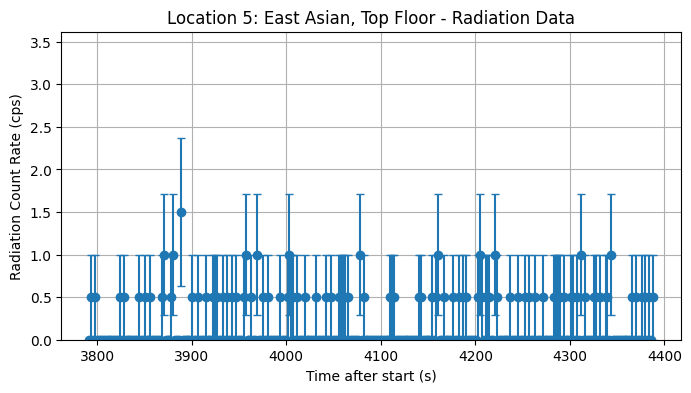

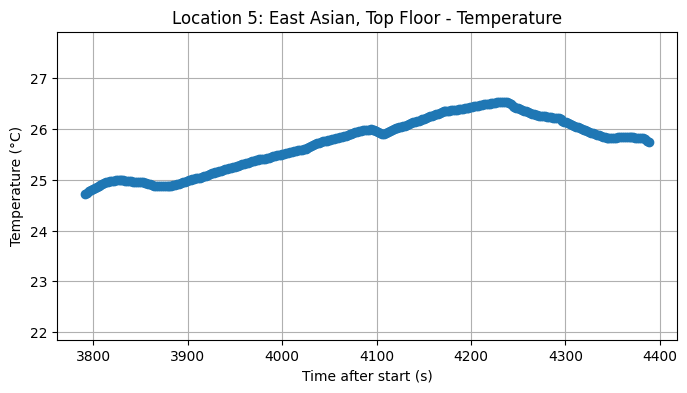

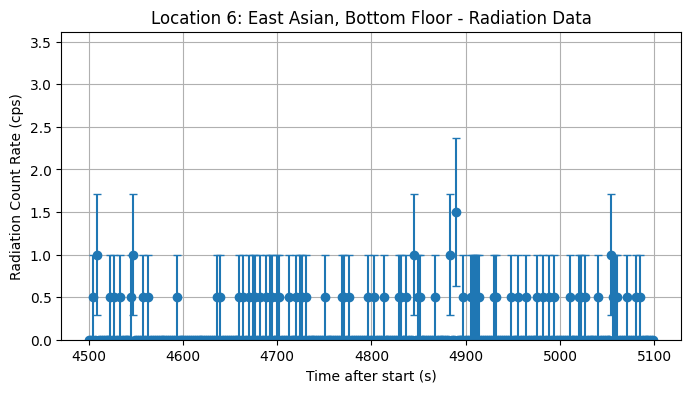

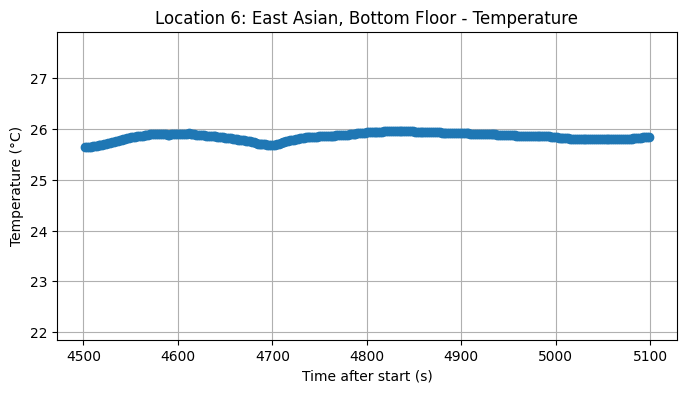

In [ ]:
# global y-axis limits

# Radiation limits
rad_ymin = (rad_df["cps"] - rad_df["cps_err"]).min()
rad_ymax = (rad_df["cps"] + rad_df["cps_err"]).max()

# Temperature limits
temp_ymin = (temp_df["temp_mean"] - temp_df["temp_err"]).min()
temp_ymax = (temp_df["temp_mean"] + temp_df["temp_err"]).max()


# time dependence graphs
for location, (start, end) in locations.items():

    rad_loc = rad_df[
        (rad_df["time_s"] >= start) & (rad_df["time_s"] <= end)
    ]

    temp_loc = temp_df[
        (temp_df["time_s"] >= start) & (temp_df["time_s"] <= end)
    ]

    # Radiation plot
    plt.figure(figsize=(8, 4))

    plt.errorbar(
        rad_loc["time_s"],
        rad_loc["cps"],
        yerr=rad_loc["cps_err"],
        fmt="o",
        capsize=3
    )

    plt.title(location + " - Radiation Data")
    plt.xlabel("Time after start (s)")
    plt.ylabel("Radiation Count Rate (cps)")

    #y-axis for all radiation graphs
    plt.ylim(rad_ymin, rad_ymax)

    plt.grid(True)
    plt.show()


    # Temperature plot
    plt.figure(figsize=(8, 4))

    plt.errorbar(
        temp_loc["time_s"],
        temp_loc["temp_mean"],
        yerr=temp_loc["temp_err"],
        fmt="o",
        capsize=3
    )

    plt.title(location + " - Temperature")
    plt.xlabel("Time after start (s)")
    plt.ylabel("Temperature (°C)")

    #y-axis for all temperature graphs
    plt.ylim(temp_ymin, temp_ymax)

    plt.grid(True)
    plt.show()

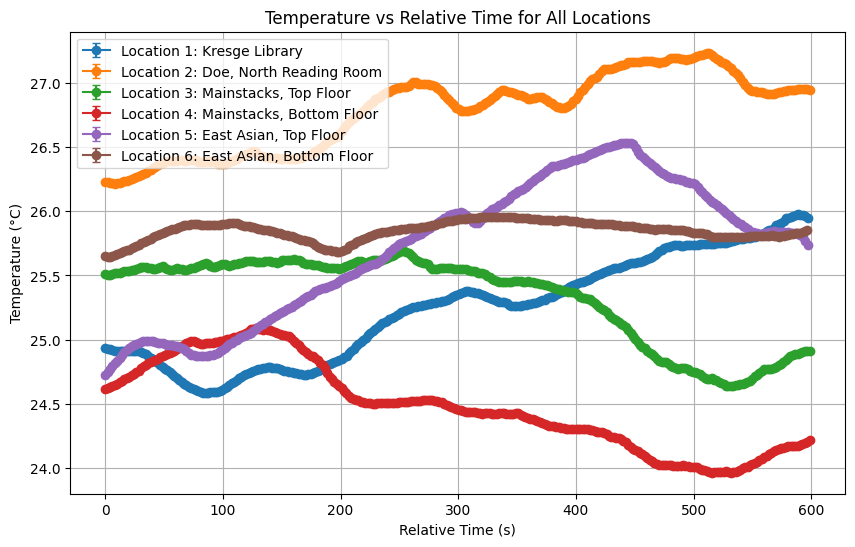

In [ ]:
plt.figure(figsize=(10, 6))

# temperature locations
for location, (start, end) in locations.items():

    temp_loc = temp_df[
        (temp_df["time_s"] >= start) &
        (temp_df["time_s"] <= end)
    ].copy()

    # Resetting each location's time axis to start at 0
    temp_loc["relative_time_s"] = temp_loc["time_s"] - temp_loc["time_s"].min()

    plt.errorbar(
        temp_loc["relative_time_s"],
        temp_loc["temp_mean"],
        yerr=temp_loc["temp_err"],
        fmt="o-",
        capsize=3,
        label=location
    )

plt.title("Temperature vs Relative Time for All Locations")
plt.xlabel("Relative Time (s)")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.legend()

plt.show()

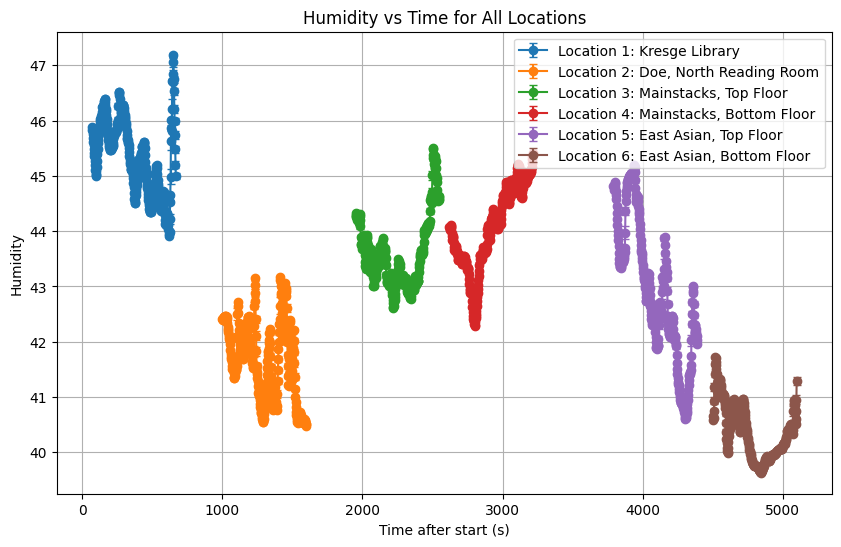

In [ ]:
plt.figure(figsize=(10, 6))

#temperature locations on the same graph
for location, (start, end) in locations.items():

    temp_loc = temp_df[
        (temp_df["time_s"] >= start) &
        (temp_df["time_s"] <= end)
    ]

    plt.errorbar(
        temp_loc["time_s"],
        temp_loc["hum_mean"],
        yerr=temp_loc["hum_err"],
        fmt="o-",
        capsize=3,
        label=location
    )

plt.title("Humidity vs Time for All Locations")
plt.xlabel("Time after start (s)")
plt.ylabel("Humidity")

plt.grid(True)
plt.legend()

plt.show()

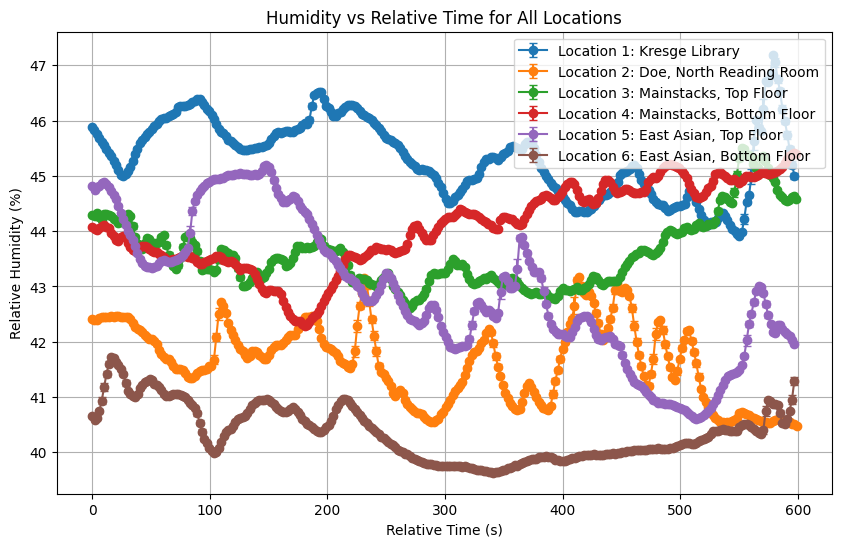

In [ ]:
plt.figure(figsize=(10, 6))

# humidity locations
for location, (start, end) in locations.items():

    hum_loc = temp_df[
        (temp_df["time_s"] >= start) &
        (temp_df["time_s"] <= end)
    ].copy()

    # Resetting each location's time axis to start at 0
    hum_loc["relative_time_s"] = hum_loc["time_s"] - hum_loc["time_s"].min()

    plt.errorbar(
        hum_loc["relative_time_s"],
        hum_loc["hum_mean"],
        yerr=hum_loc["hum_err"],
        fmt="o-",
        capsize=3,
        label=location
    )

plt.title("Humidity vs Relative Time for All Locations")
plt.xlabel("Relative Time (s)")
plt.ylabel("Relative Humidity (%)")

plt.grid(True)
plt.legend()

plt.show()

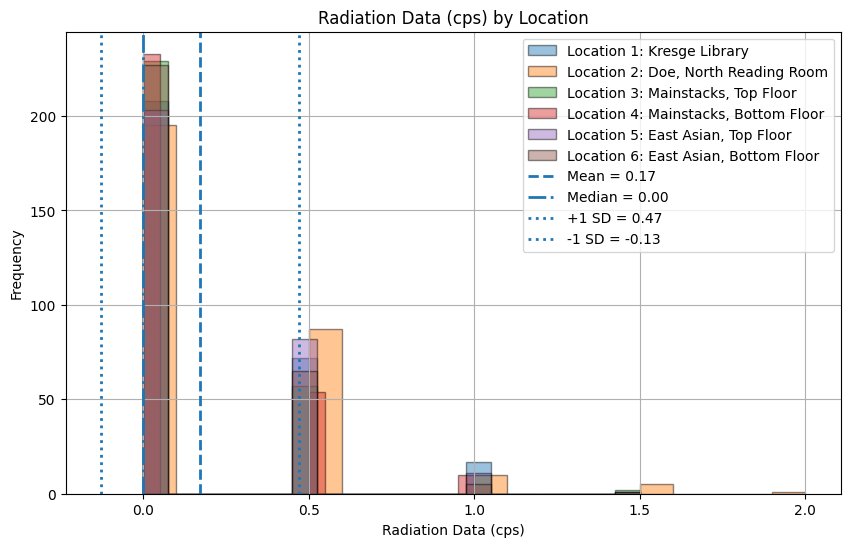

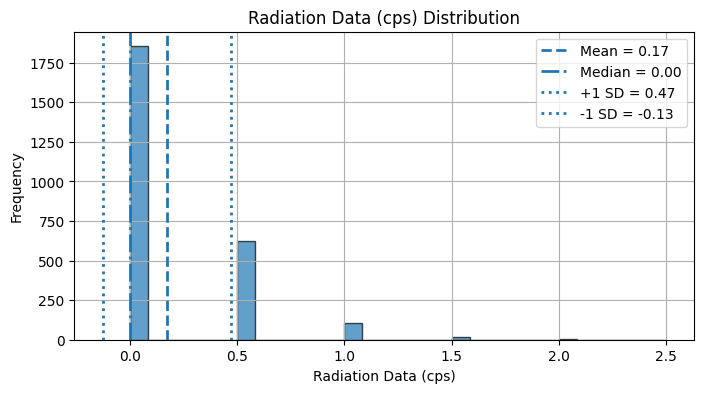

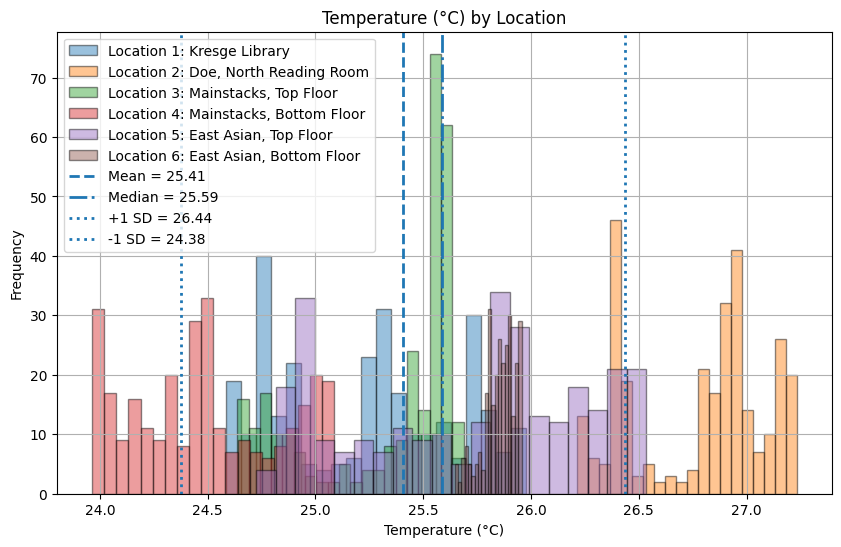

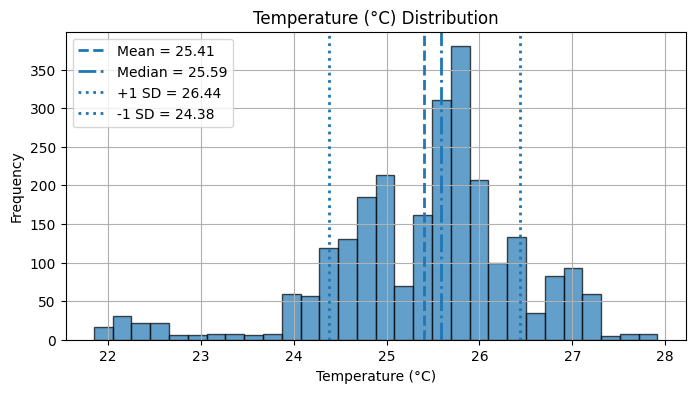

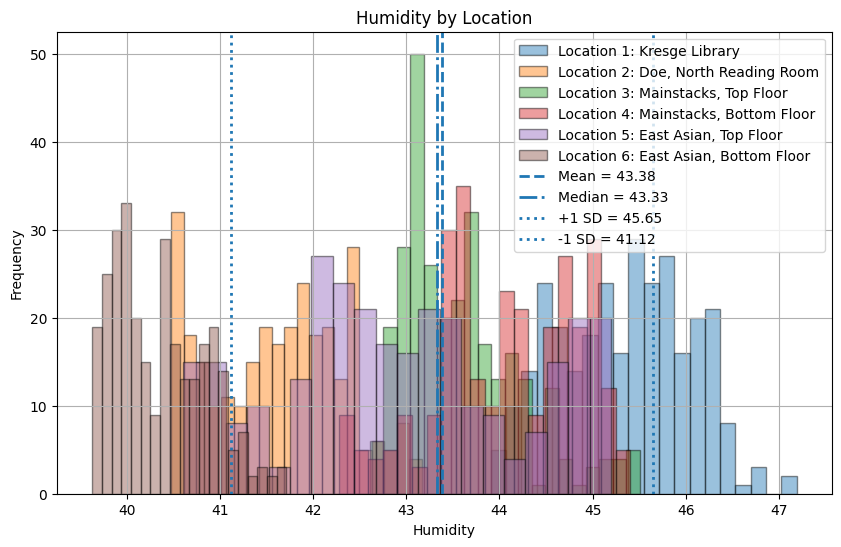

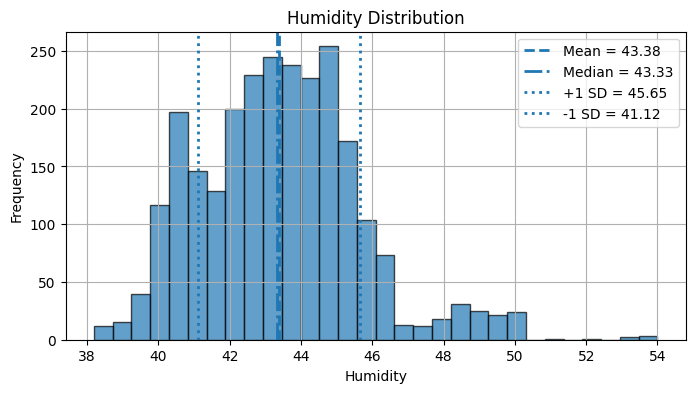

In [ ]:
# Histograms for radiation, temperature, and humidity

datasets = {
    "Radiation Data (cps)": (rad_df, "cps"),
    "Temperature (°C)": (temp_df, "temp_mean"),
    "Humidity": (temp_df, "hum_mean")
}

for title, (df, value_col) in datasets.items():

    plt.figure(figsize=(10, 6))

    for location, (start, end) in locations.items():

        loc_data = df[
            (df["time_s"] >= start) &
            (df["time_s"] <= end)
        ][value_col].dropna()

        if len(loc_data) == 0:
            continue

        plt.hist(
            loc_data,
            bins=20,
            alpha=0.45,
            edgecolor="black",
            label=location
        )

    overall_data = df[value_col].dropna()
    mean = overall_data.mean()
    median = overall_data.median()
    sd = overall_data.std(ddof=1)

    plt.axvline(mean, linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")
    plt.axvline(median, linestyle="-.", linewidth=2, label=f"Median = {median:.2f}")
    plt.axvline(mean + sd, linestyle=":", linewidth=2, label=f"+1 SD = {mean + sd:.2f}")
    plt.axvline(mean - sd, linestyle=":", linewidth=2, label=f"-1 SD = {mean - sd:.2f}")

    plt.title(title + " by Location")
    plt.xlabel(title)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.legend()
    plt.show()


    #overall histogram
    plt.figure(figsize=(8, 4))

    plt.hist(
        overall_data,
        bins=30,
        alpha=0.7,
        edgecolor="black"
    )

    plt.axvline(mean, linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")
    plt.axvline(median, linestyle="-.", linewidth=2, label=f"Median = {median:.2f}")
    plt.axvline(mean + sd, linestyle=":", linewidth=2, label=f"+1 SD = {mean + sd:.2f}")
    plt.axvline(mean - sd, linestyle=":", linewidth=2, label=f"-1 SD = {mean - sd:.2f}")

    plt.title(title + " Distribution")
    plt.xlabel(title)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
# mean, median, and variance table
# as variance is sample variance, ddof = 1

summary_rows = []

def get_stats(df, value_col, start=None, end=None):
    if start is not None and end is not None:
        data = df[
            (df["time_s"] >= start) &
            (df["time_s"] <= end)
        ][value_col].dropna()
    else:
        data = df[value_col].dropna()

    return data.mean(), data.median(), data.var(ddof=1)


#overall row
rad_mean, rad_median, rad_var = get_stats(rad_df, "cps")
temp_mean, temp_median, temp_var = get_stats(temp_df, "temp_mean")
hum_mean, hum_median, hum_var = get_stats(temp_df, "hum_mean")

summary_rows.append({
    "Location": "All",
    "Radiation Data (cps) – Mean": rad_mean,
    "Temperature (°C) – Mean": temp_mean,
    "Humidity – Mean": hum_mean,
    "Radiation Data (cps) – Median": rad_median,
    "Temperature (°C) – Median": temp_median,
    "Humidity – Median": hum_median,
    "Radiation Data (cps) – Variance": rad_var,
    "Temperature (°C) – Variance": temp_var,
    "Humidity – Variance": hum_var
})


#location rows
for location, (start, end) in locations.items():

    rad_mean, rad_median, rad_var = get_stats(rad_df, "cps", start, end)
    temp_mean, temp_median, temp_var = get_stats(temp_df, "temp_mean", start, end)
    hum_mean, hum_median, hum_var = get_stats(temp_df, "hum_mean", start, end)

    summary_rows.append({
        "Location": location,
        "Radiation Data (cps) – Mean": rad_mean,
        "Temperature (°C) – Mean": temp_mean,
        "Humidity – Mean": hum_mean,
        "Radiation Data (cps) – Median": rad_median,
        "Temperature (°C) – Median": temp_median,
        "Humidity – Median": hum_median,
        "Radiation Data (cps) – Variance": rad_var,
        "Temperature (°C) – Variance": temp_var,
        "Humidity – Variance": hum_var
    })


summary_table = pd.DataFrame(summary_rows)

numeric_cols = summary_table.columns.drop("Location")
summary_table[numeric_cols] = summary_table[numeric_cols].round(3)

styled_table = (
    summary_table.style
    .hide(axis="index")
    .set_properties(**{
        "background-color": "#3f3f3f",
        "color": "white",
        "border": "1px solid #3f3f3f",
        "text-align": "center"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#262626"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #262626")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "10px")
            ]
        }
    ])
)

display(styled_table)

Location,Radiation Data (cps) – Mean,Temperature (°C) – Mean,Humidity – Mean,Radiation Data (cps) – Median,Temperature (°C) – Median,Humidity – Median,Radiation Data (cps) – Variance,Temperature (°C) – Variance,Humidity – Variance
All,0.171000,25.408000,43.381000,0.000000,25.586000,43.333000,0.089000,1.060000,5.135000
Location 1: Kresge Library,0.183000,25.237000,45.342000,0.000000,25.283000,45.417000,0.092000,0.170000,0.477000
"Location 2: Doe, North Reading Room",0.211000,26.778000,41.640000,0.000000,26.878000,41.692000,0.113000,0.092000,0.505000
"Location 3: Mainstacks, Top Floor",0.139000,25.332000,43.591000,0.000000,25.530000,43.468000,0.077000,0.116000,0.403000
"Location 4: Mainstacks, Bottom Floor",0.125000,24.489000,44.074000,0.000000,24.458000,44.108000,0.064000,0.119000,0.578000
"Location 5: East Asian, Top Floor",0.180000,25.718000,42.926000,0.000000,25.834000,42.799000,0.081000,0.287000,1.641000
"Location 6: East Asian, Bottom Floor",0.131000,25.849000,40.356000,0.000000,25.859000,40.325000,0.062000,0.005000,0.247000


In [ ]:

dt = rad_df["time_s"].diff().median()
rad_df["counts"] = rad_df["cps"] * dt

N            = len(rad_df)
mean_counts  = rad_df["counts"].mean()
var_counts   = rad_df["counts"].var(ddof=1)
std_counts   = rad_df["counts"].std(ddof=1)
exp_var      = mean_counts
exp_std      = np.sqrt(mean_counts)

sigma_sigma      = std_counts / np.sqrt(2 * N)
discrepancy_sig  = abs(std_counts - exp_std) / sigma_sigma

print("Statistics")
print(f"N measurements = {N}")
print(f"Mean counts/interval = {mean_counts:.4f}")
print(f"Expected variance= {exp_var:.4f} ")
print(f"Measured variance = {var_counts:.4f}")
print(f"Ratio meas/exp var= {var_counts/exp_var:.3f}")
print()
print(f"Expected std= {exp_std:.4f}")
print(f"Measured std= {std_counts:.4f} ± {sigma_sigma:.4f}  ")
print(f"Discrepancy = {discrepancy_sig:.2f} ,  ", end="")
print("in statistical agreement" if discrepancy_sig < 2 else "not in statistical agreement")

# mean count rates
print("\n Estimated Mean Count Rate per Location ")
loc_stats = {}
for loc, (start, end) in locations.items():
    d   = rad_df[(rad_df["time_s"] >= start) & (rad_df["time_s"] <= end)]["cps"]
    n   = len(d)
    m   = d.mean()
    s   = d.std(ddof=1)
    sem = s / np.sqrt(n)
    loc_stats[loc] = dict(n=n, mean=m, std=s, sem=sem)
    print(f"  {loc}: {m:.4f} ± {sem:.4f} cps  (N={n})")

#pairwise z test
print("\n Pairwise Comparisons for z-test on means ")
locs = list(loc_stats.keys())
for i in range(len(locs)):
    for j in range(i + 1, len(locs)):
        a, b  = locs[i], locs[j]
        diff  = loc_stats[a]["mean"] - loc_stats[b]["mean"]
        se    = np.sqrt(loc_stats[a]["sem"]**2 + loc_stats[b]["sem"]**2)
        z     = diff / se
        p     = 2 * (1 - stats.norm.cdf(abs(z)))
        label = "significant" if p < 0.05 else "not significant"
        print(f"  {a.split(':')[0]} vs {b.split(':')[0]}: "
              f"Δ={diff:+.4f} cps, z={z:.2f}, p={p:.3f}  {label}")

Statistics
N measurements = 2598
Mean counts/interval = 0.3456
Expected variance= 0.3456 
Measured variance = 0.3641
Ratio meas/exp var= 1.054

Expected std= 0.5879
Measured std= 0.6034 ± 0.0084  
Discrepancy = 1.85 ,  in statistical agreement

 Estimated Mean Count Rate per Location 
  Location 1: Kresge Library: 0.1829 ± 0.0176 cps  (N=298)
  Location 2: Doe, North Reading Room: 0.2114 ± 0.0195 cps  (N=298)
  Location 3: Mainstacks, Top Floor: 0.1393 ± 0.0161 cps  (N=298)
  Location 4: Mainstacks, Bottom Floor: 0.1246 ± 0.0147 cps  (N=297)
  Location 5: East Asian, Top Floor: 0.1801 ± 0.0166 cps  (N=297)
  Location 6: East Asian, Bottom Floor: 0.1309 ± 0.0144 cps  (N=298)

 Pairwise Comparisons for z-test on means 
  Location 1 vs Location 2: Δ=-0.0285 cps, z=-1.09, p=0.277  not significant
  Location 1 vs Location 3: Δ=+0.0436 cps, z=1.83, p=0.067  not significant
  Location 1 vs Location 4: Δ=+0.0583 cps, z=2.55, p=0.011  significant
  Location 1 vs Location 5: Δ=+0.0028 cps, z=0.1